### Load libraries

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andrewmvd/road-sign-detection")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/andrewmvd/road-sign-detection


In [2]:
!ls $path

annotations  images


In [3]:
import os
import io
import shutil
import requests
import matplotlib.pyplot as plt
import numpy as np
from glob import glob
from PIL import Image
from lxml import etree
from tqdm import tqdm

In [4]:
!pip install ultralytics
from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
epochs = 20
class_dict = {"stop": 0, "speedlimit": 1, "crosswalk": 2, "trafficlight": 3}

### Convert **VOC** format to **YOLO** format

In [6]:
def split_train_test(path: str, train_size: float = 0.8, val_size: float = 0.1, seed: int = None):
    if seed is not None:
        np.random.seed(seed)

    annots = np.array(os.listdir(os.path.join(path, "annotations")))
    imgs = np.array(os.listdir(os.path.join(path, "images")))

    #sort arrays
    annots.sort()
    imgs.sort()

    train_len = int(len(annots) * train_size)
    val_len = int(len(annots) * val_size)
    test_len = len(annots) - train_len - val_len

    indices = np.arange(len(annots), dtype=int)
    np.random.shuffle(indices)

    train_idx = indices[:train_len]
    val_idx = indices[:train_len + val_len]
    test_idx = indices[train_len+val_len:]

    train_annots = annots[train_idx]
    train_imgs = imgs[train_idx]

    val_annots = annots[val_idx]
    val_imgs = imgs[val_idx]

    test_annots = annots[test_idx]
    test_imgs = imgs[test_idx]

    return (train_annots, train_imgs), (val_annots, val_imgs), (test_annots, test_imgs)

In [7]:
train, val, test = split_train_test(path, 0.8, 0.1, seed=42)

In [8]:
def extract_data(xml_file: str):
    """
    Read the xml file and return the metadata
    """
    tree = etree.parse(xml_file)
    root = tree.getroot()

    img_path = root.find("filename").text

    # image size
    size = root.find("size")
    width = int(size.find("width").text)
    height = int(size.find("height").text)

    boxes = []
    labels = []

    for obj in root.findall("object"):
        class_name = obj.find("name").text
        bndbox = obj.find("bndbox")

        xmin = int(bndbox.find("xmin").text)
        ymin = int(bndbox.find("ymin").text)
        xmax = int(bndbox.find("xmax").text)
        ymax = int(bndbox.find("ymax").text)

        labels.append(class_name)
        boxes.append([xmin, ymin, xmax, ymax])

    return img_path, width, height, boxes, labels

In [9]:
def rcnn_to_yolo(img_w, img_h, xmin, ymin, xmax, ymax):
    """
    convert RCNN format boxes to YOLO format
    """
    x_abs = (xmin + xmax) / 2
    y_abs = (ymin + ymax) / 2
    w_abs = xmax - xmin
    h_abs = ymax - ymin

    xc = x_abs / img_w
    yc = y_abs / img_h
    w = w_abs / img_w
    h = h_abs / img_h

    return xc, yc, w, h

In [10]:
def create_yolo_files(data: tuple, folder: str):
  os.makedirs(f"{folder}/labels", exist_ok=True)
  os.makedirs(f"{folder}/images", exist_ok=True)

  for (annots, imgs) in data:
    for i in tqdm(range(len(annots))):
      img_path, width, height, boxes, labels = extract_data(os.path.join(path, "annotations", annots[i]))

      # result holder
      result = []
      for j in range(len(boxes)):
         xmin, ymin, xmax, ymax = boxes[j]
         class_id = class_dict[labels[j]]

         box = rcnn_to_yolo(width, height, xmin, ymin, xmax, ymax)
         result.append(f"{class_id} {' '.join(str(x) for x in box)}")

      with open(f"{folder}/labels/{i}.txt", "w") as f:
         content = "\n".join(result)
         f.write(content)

      shutil.copy(os.path.join(path, "images", img_path), f"{folder}/images/{i}.jpg")

In [11]:
create_yolo_files([val], "data/val")
create_yolo_files([train], "data/train")
create_yolo_files([test], "data/test")

100%|██████████| 89/89 [00:01<00:00, 56.61it/s]


In [12]:
def create_yaml(root: str, train: str, valid: str, classes: list):
  """ Create dataset.yaml """
  nc = len(classes)
  content = f"""
path: {root}
train: {train}
val: {valid}

nc: {nc}
names: {classes}
  """
  with open("dataset.yaml", "w") as f:
      f.write(content)
  print("Created dataset.yaml!")

In [13]:
create_yaml("data", "train", "val", list(class_dict.keys()))

Created dataset.yaml!


In [14]:
!cat dataset.yaml


path: data
train: train
val: val

nc: 4
names: ['stop', 'speedlimit', 'crosswalk', 'trafficlight']
  

### Create model

In [15]:
model = YOLO("yolo26n.pt")

### Train the model

In [16]:
model.train(data="dataset.yaml", batch=8, epochs=epochs, imgsz=320, device=[-1, -1])

Searching for 2 idle GPUs with free memory >= 20.0% and free utilization >= 0.0%...
Selected idle CUDA devices [0, 1]
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
                                                      CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, mo

### Grab the best model and test

In [17]:
best_model = YOLO("runs/detect/train/weights/best.pt")


0: 320x256 2 speedlimits, 12.2ms
1: 320x256 1 speedlimit, 12.2ms
2: 320x256 1 speedlimit, 12.2ms
3: 320x256 1 speedlimit, 12.2ms
4: 320x256 1 speedlimit, 12.2ms
Speed: 1.1ms preprocess, 12.2ms inference, 4.7ms postprocess per image at shape (1, 3, 320, 256)


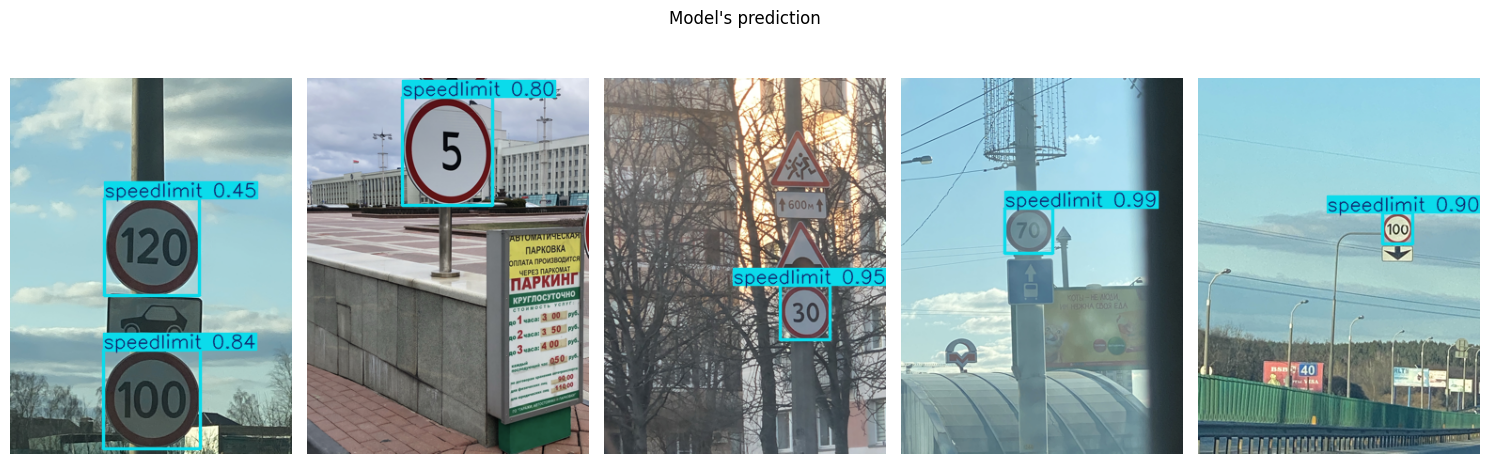

In [18]:
test_imgs = glob("data/test/images/*.jpg")

results = best_model.predict(test_imgs[:5], imgsz=320)

# Create subplots
fig, axes = plt.subplots(1, len(results), figsize=(15, 5))

for ax, result in zip(axes, results):
    img = result.plot()  # get annotated image (numpy array)
    ax.imshow(img[:, :, ::-1]) # convert BGR format to RGB
    ax.axis("off")

plt.suptitle("Model's prediction")
plt.tight_layout()
plt.show()

In [19]:
urls = [
  "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTVx3aRvG6V_iFoRfy8eZu02Oqxcga4k5aXCWi_vDERq_J66XxGuRzc0Lk9",
  "https://c8.alamy.com/comp/APMEH7/70mph-road-sign-on-the-m77near-kilmarnock-central-scotland-2006-APMEH7.jpg",
    "https://www.alamy.com/aggregator-api/download/?url=https%3A%2F%2Fc7.alamy.com%2Fcomp%2F3CME1FX%2Fsigns-on-anno-street-in-the-district-severinsviertel-in-the-southern-part-of-the-town-cologne-germany-schilder-an-der-annostrasse-im-severinsvierte-3CME1FX.jpg",
    "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTLkM8OY7RsneXSzmI1qrq9AIpJgLI9f9YYlmAAT9yoFw&s=10",
    "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSu_huwNchh-2LnwaGMEGNgYtbOtAJ-xE1cIH5a08mpuQ&s=10",
    "https://us.123rf.com/450wma/photobyphotoboy/photobyphotoboy1901/photobyphotoboy190100073/118228513-crosswalk-sign-on-the-road-for-safety-when-people-walking-the-street.avif"
 ]

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0.0.0 Safari/537.36",
    "Connection": "keep-alive",
    "Upgrade-Insecure-Requests": "1",
    "DNT": "1"
}

imgs = [requests.get(url).content for url in urls]

images = []
for i, img in enumerate(imgs):
  try:
    image = Image.open(io.BytesIO(img))
    images.append(image)
  except Exception as e:
    print(f"Error in {i+1}th image: {e}")
    continue


0: 320x320 2 stops, 11.4ms
1: 320x320 1 speedlimit, 11.4ms
2: 320x320 1 stop, 2 crosswalks, 1 trafficlight, 11.4ms
3: 320x320 1 crosswalk, 11.4ms
4: 320x320 1 crosswalk, 11.4ms
5: 320x320 2 crosswalks, 11.4ms
Speed: 1.2ms preprocess, 11.4ms inference, 0.3ms postprocess per image at shape (1, 3, 320, 320)


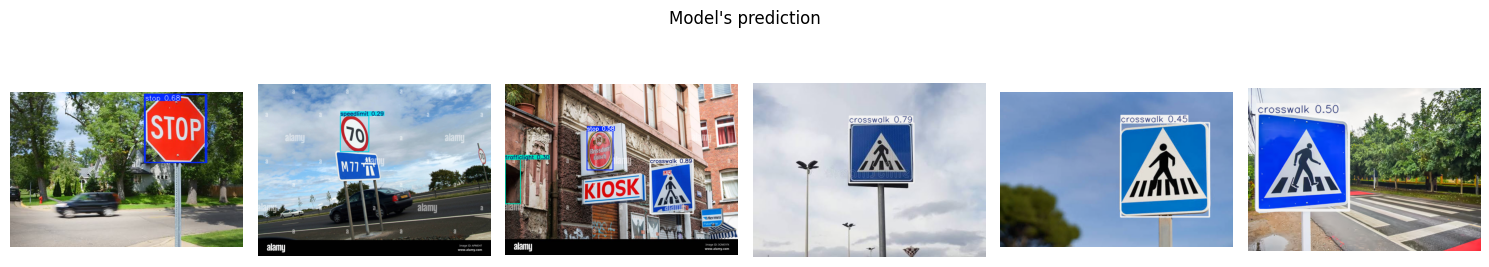

In [20]:
results = best_model.predict(images, imgsz=320)

# Create subplots
fig, axes = plt.subplots(1, len(results), figsize=(15, 3))

for ax, result in zip(axes, results):
    img = result.plot()  # get annotated image (numpy array)
    ax.imshow(img[:, :, ::-1]) # BGR -> RGB
    ax.axis("off")

plt.suptitle("Model's prediction")
plt.tight_layout()
plt.show()